<a href="https://colab.research.google.com/github/athfizh/PemMes26_05_Hafizh/blob/main/JS05/JS05-TugasLab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---


# **Klasifikasi 1 - Tugas Lab 2**


---

**Klasifikasi SMS spam pada dataset `spam.csv` menggunakan Multinomial Naive Bayes**

**Tugas 1** - Model Multinomial Naive Bayes dengan data `spam.csv`, fitur `CountVectorizer` dengan mengaktifkan `stop_words`, dan evaluasi hasilnya.

**Tugas 2** - Model Multinomial Naive Bayes dengan data `spam.csv`, fitur `TF-IDF` dengan mengaktifkan `stop_words`, evaluasi hasilnya dan dibandingkan dengan hasil fitur `CountVectorizer` pada Tugas 1, serta kesimpulan fitur mana yang terbaik pada kasus data `spam.csv`.

---


# **Langkah 1 - Load Data**


---

In [1]:
# Load data
import pandas as pd

df = pd.read_csv('/content/spam.csv', encoding='latin-1')  # encoding diperlukan karena data tidak menggunakan UTF-8
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


---


# **Langkah 2 - Preprocessing**


---

Beberapa hal yang akan dilakukan pada tahap ini yaitu,

- Drop kolom yang tidak digunakan

- Ubah nama kolom v1 (label) dan v2 (teks sms)

- Inspeksi Data

- Encode label

- Memisahkan fitur dengan label dan membagi data training dan testing

**Langkah 2a - Drop Kolom**

In [2]:
# Drop 3 kolom terakhir dengan fungsi iloc
df = df.drop(df.iloc[:, 2:], axis=1)

# Cek data
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


**Langkah 2b - Ubah Nama Kolom dan Inspeksi Data**

In [3]:
# Ubah nama kolom v1 (label) dan v2 (teks sms)
df = df.rename(columns={'v1': 'Labels', 'v2': 'SMS'})

# Cek Jumlah Data Per Kelas
print(df['Labels'].value_counts())
print('\n')

# Cek Kelengkapan Data
print(df.info())
print('\n')

# Cek Statistik Deskriptif
print(df.describe())

Labels
ham     4825
spam     747
Name: count, dtype: int64


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Labels  5572 non-null   object
 1   SMS     5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None


       Labels                     SMS
count    5572                    5572
unique      2                    5169
top       ham  Sorry, I'll call later
freq     4825                      30


**Langkah 2c - Encoding Label**

In [4]:
# Data untuk label
new_labels = {
    'spam': 1,
    'ham': 0
}

# Encode label
df['Labels'] = df['Labels'].map(new_labels)

# Cek data
df.head()

,Labels,SMS
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


**Langkah 2d - Pisahkan Fitur dengan Label dan Split Data**

Data training dan testing yang **sama** digunakan untuk kedua fitur (CountVectorizer dan TF-IDF) agar perbandingannya adil.

In [5]:
from sklearn.model_selection import train_test_split

X = df['SMS'].values
y = df['Labels'].values

# Split data training dan testing (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50)

print('Data train:', X_train.shape[0])
print('Data test :', X_test.shape[0])

Data train: 4457
Data test : 1115


---


# **Langkah 3 - Tugas 1: Multinomial Naive Bayes dengan CountVectorizer (stop_words aktif)**


---

**Langkah 3a - Ekstraksi Fitur**

Parameter `stop_words='english'` membuang kata-kata umum (seperti *the*, *is*, *and*) yang kurang membantu dalam membedakan spam dan ham.

In [6]:
from sklearn.feature_extraction.text import CountVectorizer

# Inisiasi CountVectorizer dengan stop_words aktif
bow = CountVectorizer(stop_words='english')

# Fitting dan transform X_train dengan CountVectorizer
X_train_bow = bow.fit_transform(X_train)

# Transform X_test
# Hanya transform agar data testing tetap menjadi data yang asing bagi model
X_test_bow = bow.transform(X_test)

print('Dimensi data train:', X_train_bow.shape)
print('Jumlah fitur (kata):', len(bow.vocabulary_))

Dimensi data train: (4457, 7466)
Jumlah fitur (kata): 7466


**Langkah 3b - Training Model**

In [7]:
from sklearn.naive_bayes import MultinomialNB

# Inisiasi MultinomialNB
mnb_bow = MultinomialNB()

# Fit model
mnb_bow.fit(X_train_bow, y_train)

MultinomialNB()

**Langkah 3c - Evaluasi Model**

In [8]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Prediksi data training dan testing
y_pred_train_bow = mnb_bow.predict(X_train_bow)
y_pred_bow = mnb_bow.predict(X_test_bow)

# Print hasil evaluasi
print('Hasil akurasi data train:', accuracy_score(y_train, y_pred_train_bow))
print('Hasil akurasi data test :', accuracy_score(y_test, y_pred_bow))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred_bow))
print('\nLaporan Klasifikasi:\n', classification_report(y_test, y_pred_bow, target_names=['ham', 'spam']))

Hasil akurasi data train: 0.9946152120260264
Hasil akurasi data test : 0.9829596412556054

Confusion Matrix:
 [[951   3]
 [ 16 145]]

Laporan Klasifikasi:
               precision    recall  f1-score   support

         ham       0.98      1.00      0.99       954
        spam       0.98      0.90      0.94       161

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



---


# **Langkah 4 - Tugas 2: Multinomial Naive Bayes dengan TF-IDF (stop_words aktif)**


---

**Langkah 4a - Ekstraksi Fitur**

`TfidfVectorizer` mengubah teks menjadi matriks kata dengan bobot TF-IDF (bukan jumlah kemunculan kata). Parameter `stop_words='english'` juga diaktifkan.

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Inisiasi TfidfVectorizer dengan stop_words aktif
tfidf = TfidfVectorizer(stop_words='english')

# Fitting dan transform X_train dengan TF-IDF
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform X_test
X_test_tfidf = tfidf.transform(X_test)

print('Dimensi data train:', X_train_tfidf.shape)
print('Jumlah fitur (kata):', len(tfidf.vocabulary_))

Dimensi data train: (4457, 7466)
Jumlah fitur (kata): 7466


**Langkah 4b - Training Model**

In [10]:
# Inisiasi MultinomialNB
mnb_tfidf = MultinomialNB()

# Fit model
mnb_tfidf.fit(X_train_tfidf, y_train)

MultinomialNB()

**Langkah 4c - Evaluasi Model**

In [11]:
# Prediksi data training dan testing
y_pred_train_tfidf = mnb_tfidf.predict(X_train_tfidf)
y_pred_tfidf = mnb_tfidf.predict(X_test_tfidf)

# Print hasil evaluasi
print('Hasil akurasi data train:', accuracy_score(y_train, y_pred_train_tfidf))
print('Hasil akurasi data test :', accuracy_score(y_test, y_pred_tfidf))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred_tfidf))
print('\nLaporan Klasifikasi:\n', classification_report(y_test, y_pred_tfidf, target_names=['ham', 'spam']))

Hasil akurasi data train: 0.9842943684092439
Hasil akurasi data test : 0.9605381165919282

Confusion Matrix:
 [[954   0]
 [ 44 117]]

Laporan Klasifikasi:
               precision    recall  f1-score   support

         ham       0.96      1.00      0.98       954
        spam       1.00      0.73      0.84       161

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115



---


# **Langkah 5 - Perbandingan TF-IDF dengan CountVectorizer**


---

Hasil evaluasi fitur TF-IDF (Tugas 2) dibandingkan dengan hasil fitur CountVectorizer (Tugas 1) pada data testing yang sama. Precision, recall, dan F1-score dihitung untuk kelas **spam** karena kelas inilah yang ingin dideteksi.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

def metrik(y_true, y_pred):
    return [accuracy_score(y_true, y_pred), precision_score(y_true, y_pred), recall_score(y_true, y_pred), f1_score(y_true, y_pred)]

nama_metrik = ['Akurasi', 'Precision (spam)', 'Recall (spam)', 'F1-score (spam)']

hasil = pd.DataFrame({
    'Metrik': nama_metrik,
    'CountVectorizer': np.round(metrik(y_test, y_pred_bow), 4),
    'TF-IDF': np.round(metrik(y_test, y_pred_tfidf), 4)
})
hasil['Selisih (CountVectorizer - TF-IDF)'] = (hasil['CountVectorizer'] - hasil['TF-IDF']).round(4)
hasil

,Metrik,CountVectorizer,TF-IDF,Selisih (CountVectorizer - TF-IDF)
0,Akurasi,0.9830,0.9605,0.0225
1,Precision (spam),0.9797,1.0000,-0.0203
2,Recall (spam),0.9006,0.7267,0.1739
3,F1-score (spam),0.9385,0.8417,0.0968


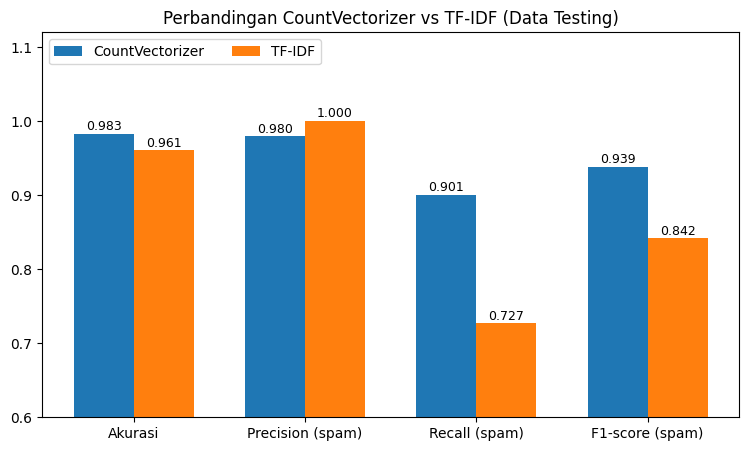

In [13]:
x = np.arange(len(nama_metrik))
lebar = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - lebar / 2, hasil['CountVectorizer'], lebar, label='CountVectorizer')
plt.bar(x + lebar / 2, hasil['TF-IDF'], lebar, label='TF-IDF')
for i, (a, b) in enumerate(zip(hasil['CountVectorizer'], hasil['TF-IDF'])):
    plt.text(i - lebar / 2, a + 0.005, f'{a:.3f}', ha='center', fontsize=9)
    plt.text(i + lebar / 2, b + 0.005, f'{b:.3f}', ha='center', fontsize=9)
plt.xticks(x, nama_metrik)
plt.ylim(0.6, 1.12)
plt.title('Perbandingan CountVectorizer vs TF-IDF (Data Testing)')
plt.legend(loc='upper left', ncol=2)
plt.show()

---


# **Langkah 6 - Kesimpulan**


---

**Tugas 1 - Multinomial Naive Bayes dengan CountVectorizer (stop_words aktif)**

Akurasi data testing 0.9830. Dari 161 SMS spam, 145 berhasil terdeteksi (16 lolos), dan 3 dari 954 SMS ham salah dianggap spam.

**Tugas 2 - Multinomial Naive Bayes dengan TF-IDF (stop_words aktif)**

Akurasi data testing 0.9605. Dari 161 SMS spam, 117 berhasil terdeteksi (44 lolos), dan tidak ada SMS ham yang salah dianggap spam.

**Perbandingan pada data testing**

| Metrik | CountVectorizer | TF-IDF |
|---|---|---|
| Akurasi | **0.9830** | 0.9605 |
| Precision (spam) | 0.9797 | **1.0000** |
| Recall (spam) | **0.9006** | 0.7267 |
| F1-score (spam) | **0.9385** | 0.8417 |

**Kesimpulan - fitur terbaik pada kasus data `spam.csv`**

Fitur terbaik adalah **CountVectorizer** (dengan `stop_words` aktif). Alasannya,

- CountVectorizer unggul pada akurasi (0.9830 berbanding 0.9605), recall spam (0.9006 berbanding 0.7267), dan F1-score spam (0.9385 berbanding 0.8417).
- Data `spam.csv` tidak seimbang (ham 4825 dan spam 747), sehingga recall dan F1-score kelas spam lebih menentukan daripada akurasi saja. TF-IDF melewatkan jauh lebih banyak SMS spam (44 SMS) dibandingkan CountVectorizer (16 SMS).
- TF-IDF memang memiliki precision sempurna (1.0000, tidak ada SMS ham yang salah diblokir), tetapi selisih precision-nya kecil (0.0203) dibandingkan selisih recall-nya (0.1739), sehingga secara keseluruhan CountVectorizer tetap lebih baik.